In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load customer dataset

data = pd.read_csv("WA_FnUseC_TelcoCustomerChurn.csv")

# Convert TotalCharges to numeric
data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce"
)

# Remove rows with missing TotalCharges
data = data.dropna(subset=["TotalCharges"])

# Select customer behavior features
features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

X_cluster = data[features].copy()

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print("Dataset prepared successfully!")
print("Features:", features)
print("Data shape:", X_scaled.shape)

Dataset prepared successfully!
Features: ['tenure', 'MonthlyCharges', 'TotalCharges']
Data shape: (7032, 3)


In [3]:
# Apply Elbow Method

inertia_values = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia_values.append(kmeans.inertia_)

elbow_results = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertia_values
})

print(elbow_results)

    K      Inertia
0   2  9700.829985
1   3  6176.723824
2   4  4144.587713
3   5  3108.410479
4   6  2559.841473
5   7  2177.749626
6   8  1861.116632
7   9  1629.203818
8  10  1410.825380


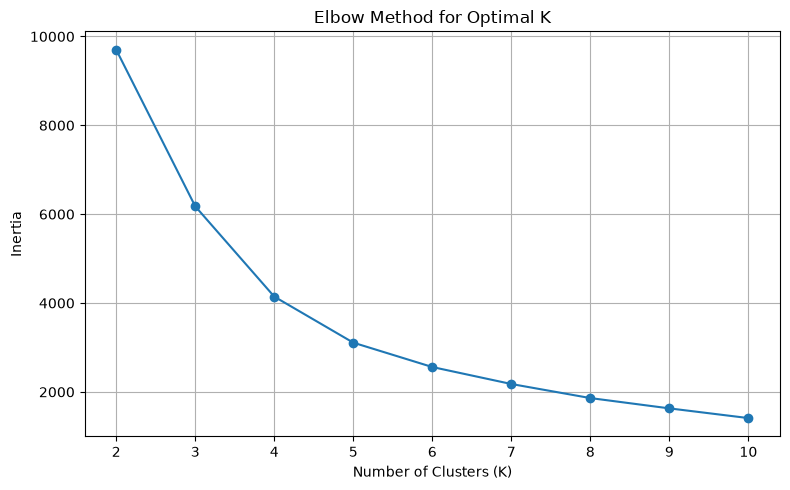

In [4]:
# Elbow Method visualization

plt.figure(figsize=(8, 5))

plt.plot(
    elbow_results["K"],
    elbow_results["Inertia"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.xticks(list(k_values))
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "elbow_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [5]:
# Calculate Silhouette Scores for different K values

silhouette_values = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_values.append(score)

silhouette_results = pd.DataFrame({
    "K": list(k_values),
    "Silhouette Score": silhouette_values
})

print(silhouette_results)

    K  Silhouette Score
0   2          0.479524
1   3          0.451513
2   4          0.472085
3   5          0.443269
4   6          0.437604
5   7          0.431087
6   8          0.427332
7   9          0.430483
8  10          0.436586


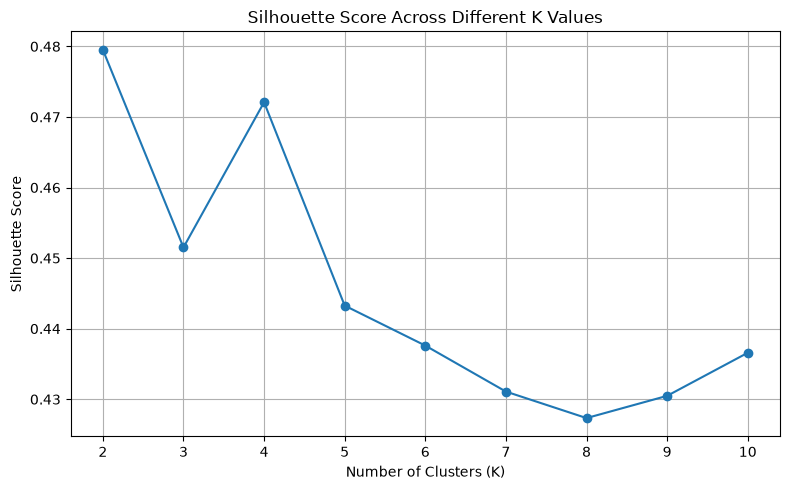

In [6]:
# Silhouette Score visualization

plt.figure(figsize=(8, 5))

plt.plot(
    silhouette_results["K"],
    silhouette_results["Silhouette Score"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score Across Different K Values")
plt.xticks(list(k_values))
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "silhouette_optimization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
# Identify K with the highest silhouette score

best_k_silhouette = int(
    silhouette_results.loc[
        silhouette_results["Silhouette Score"].idxmax(),
        "K"
    ]
)

best_silhouette = silhouette_results["Silhouette Score"].max()

print("K with highest Silhouette Score:", best_k_silhouette)
print(f"Silhouette Score: {best_silhouette:.4f}")

K with highest Silhouette Score: 2
Silhouette Score: 0.4795


In [8]:
# Compare clustering quality metrics

optimization_results = elbow_results.merge(
    silhouette_results,
    on="K"
)

print("Clustering Optimization Results:")
print(optimization_results)

optimization_results.to_csv(
    "clustering_optimization_results.csv",
    index=False
)

print("\nOptimization results saved successfully!")

Clustering Optimization Results:
    K      Inertia  Silhouette Score
0   2  9700.829985          0.479524
1   3  6176.723824          0.451513
2   4  4144.587713          0.472085
3   5  3108.410479          0.443269
4   6  2559.841473          0.437604
5   7  2177.749626          0.431087
6   8  1861.116632          0.427332
7   9  1629.203818          0.430483
8  10  1410.825380          0.436586

Optimization results saved successfully!


In [9]:
# Select final K based on the highest Silhouette Score

final_k = best_k_silhouette

print("Final selected K:", final_k)

Final selected K: 2


In [10]:
# Train final optimized K-Means model

final_kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

data["Cluster"] = final_kmeans.fit_predict(X_scaled)

print("Final clustering completed!")
print("\nCustomers in each cluster:")
print(data["Cluster"].value_counts().sort_index())

Final clustering completed!

Customers in each cluster:
Cluster
0    2360
1    4672
Name: count, dtype: int64


In [11]:
# Analyze final customer segments

final_segment_summary = (
    data.groupby("Cluster")[features]
    .agg(["mean", "count"])
    .round(2)
)

print("Final Customer Segment Analysis:")
print(final_segment_summary)

Final Customer Segment Analysis:
        tenure       MonthlyCharges       TotalCharges      
          mean count           mean count         mean count
Cluster                                                     
0        56.87  2360          89.76  2360      5084.99  2360
1        20.07  4672          52.19  4672       868.07  4672


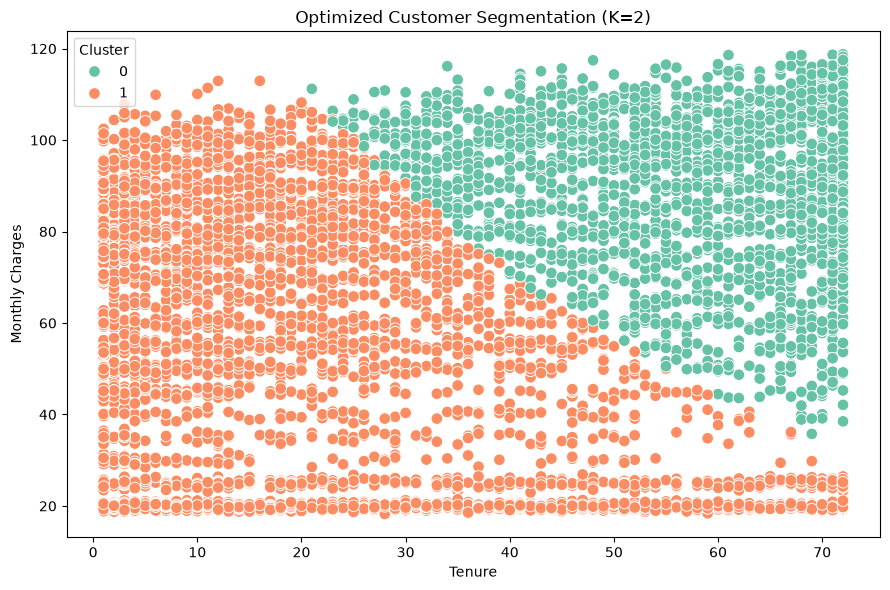

In [12]:
# Final customer segment visualization

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=data,
    x="tenure",
    y="MonthlyCharges",
    hue="Cluster",
    palette="Set2",
    s=70
)

plt.title(f"Optimized Customer Segmentation (K={final_k})")
plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")
plt.legend(title="Cluster")

plt.tight_layout()

plt.savefig(
    "optimized_customer_segments.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
# Create segment profile

segment_profile = data.groupby("Cluster")[features].mean().round(2)

segment_profile["Customer Count"] = (
    data["Cluster"].value_counts()
    .sort_index()
)

print("Final Segment Profile:")
print(segment_profile)

Final Segment Profile:
         tenure  MonthlyCharges  TotalCharges  Customer Count
Cluster                                                      
0         56.87           89.76       5084.99            2360
1         20.07           52.19        868.07            4672


In [14]:
# Save final segmentation strategy data

segment_profile.to_csv(
    "final_segmentation_strategy.csv"
)

optimization_results.to_csv(
    "clustering_optimization_results.csv",
    index=False
)

print("Final segmentation reports saved successfully!")

Final segmentation reports saved successfully!


In [15]:
# Generate business segmentation strategy

strategy_lines = []

for cluster in sorted(segment_profile.index):

    tenure = segment_profile.loc[cluster, "tenure"]
    monthly = segment_profile.loc[cluster, "MonthlyCharges"]
    total = segment_profile.loc[cluster, "TotalCharges"]
    count = int(segment_profile.loc[cluster, "Customer Count"])

    strategy_lines.append(
        f"Cluster {cluster}: "
        f"{count} customers, average tenure {tenure:.2f} months, "
        f"average monthly charges ${monthly:.2f}, "
        f"average total charges ${total:.2f}."
    )

print("FINAL BUSINESS SEGMENTATION STRATEGY")
print("=" * 50)

for line in strategy_lines:
    print(line)

FINAL BUSINESS SEGMENTATION STRATEGY
Cluster 0: 2360 customers, average tenure 56.87 months, average monthly charges $89.76, average total charges $5084.99.
Cluster 1: 4672 customers, average tenure 20.07 months, average monthly charges $52.19, average total charges $868.07.


In [16]:
# Save business segmentation strategy

with open("segmentation_strategy_report.txt", "w") as file:
    file.write("FINAL BUSINESS SEGMENTATION STRATEGY\n")
    file.write("=" * 50 + "\n\n")

    file.write(
        f"Selected number of clusters: K={final_k}\n"
    )

    file.write(
        f"Highest silhouette score: {best_silhouette:.4f}\n\n"
    )

    for line in strategy_lines:
        file.write(line + "\n")

    file.write("\nBusiness Application:\n")
    file.write(
        "The identified customer segments can support targeted "
        "marketing, retention, customer-service, and pricing strategies. "
        "The segment characteristics should be interpreted using the "
        "observed tenure and spending patterns rather than assuming "
        "customer behavior that is not represented in the data.\n"
    )

print("Segmentation strategy report saved successfully!")

Segmentation strategy report saved successfully!
